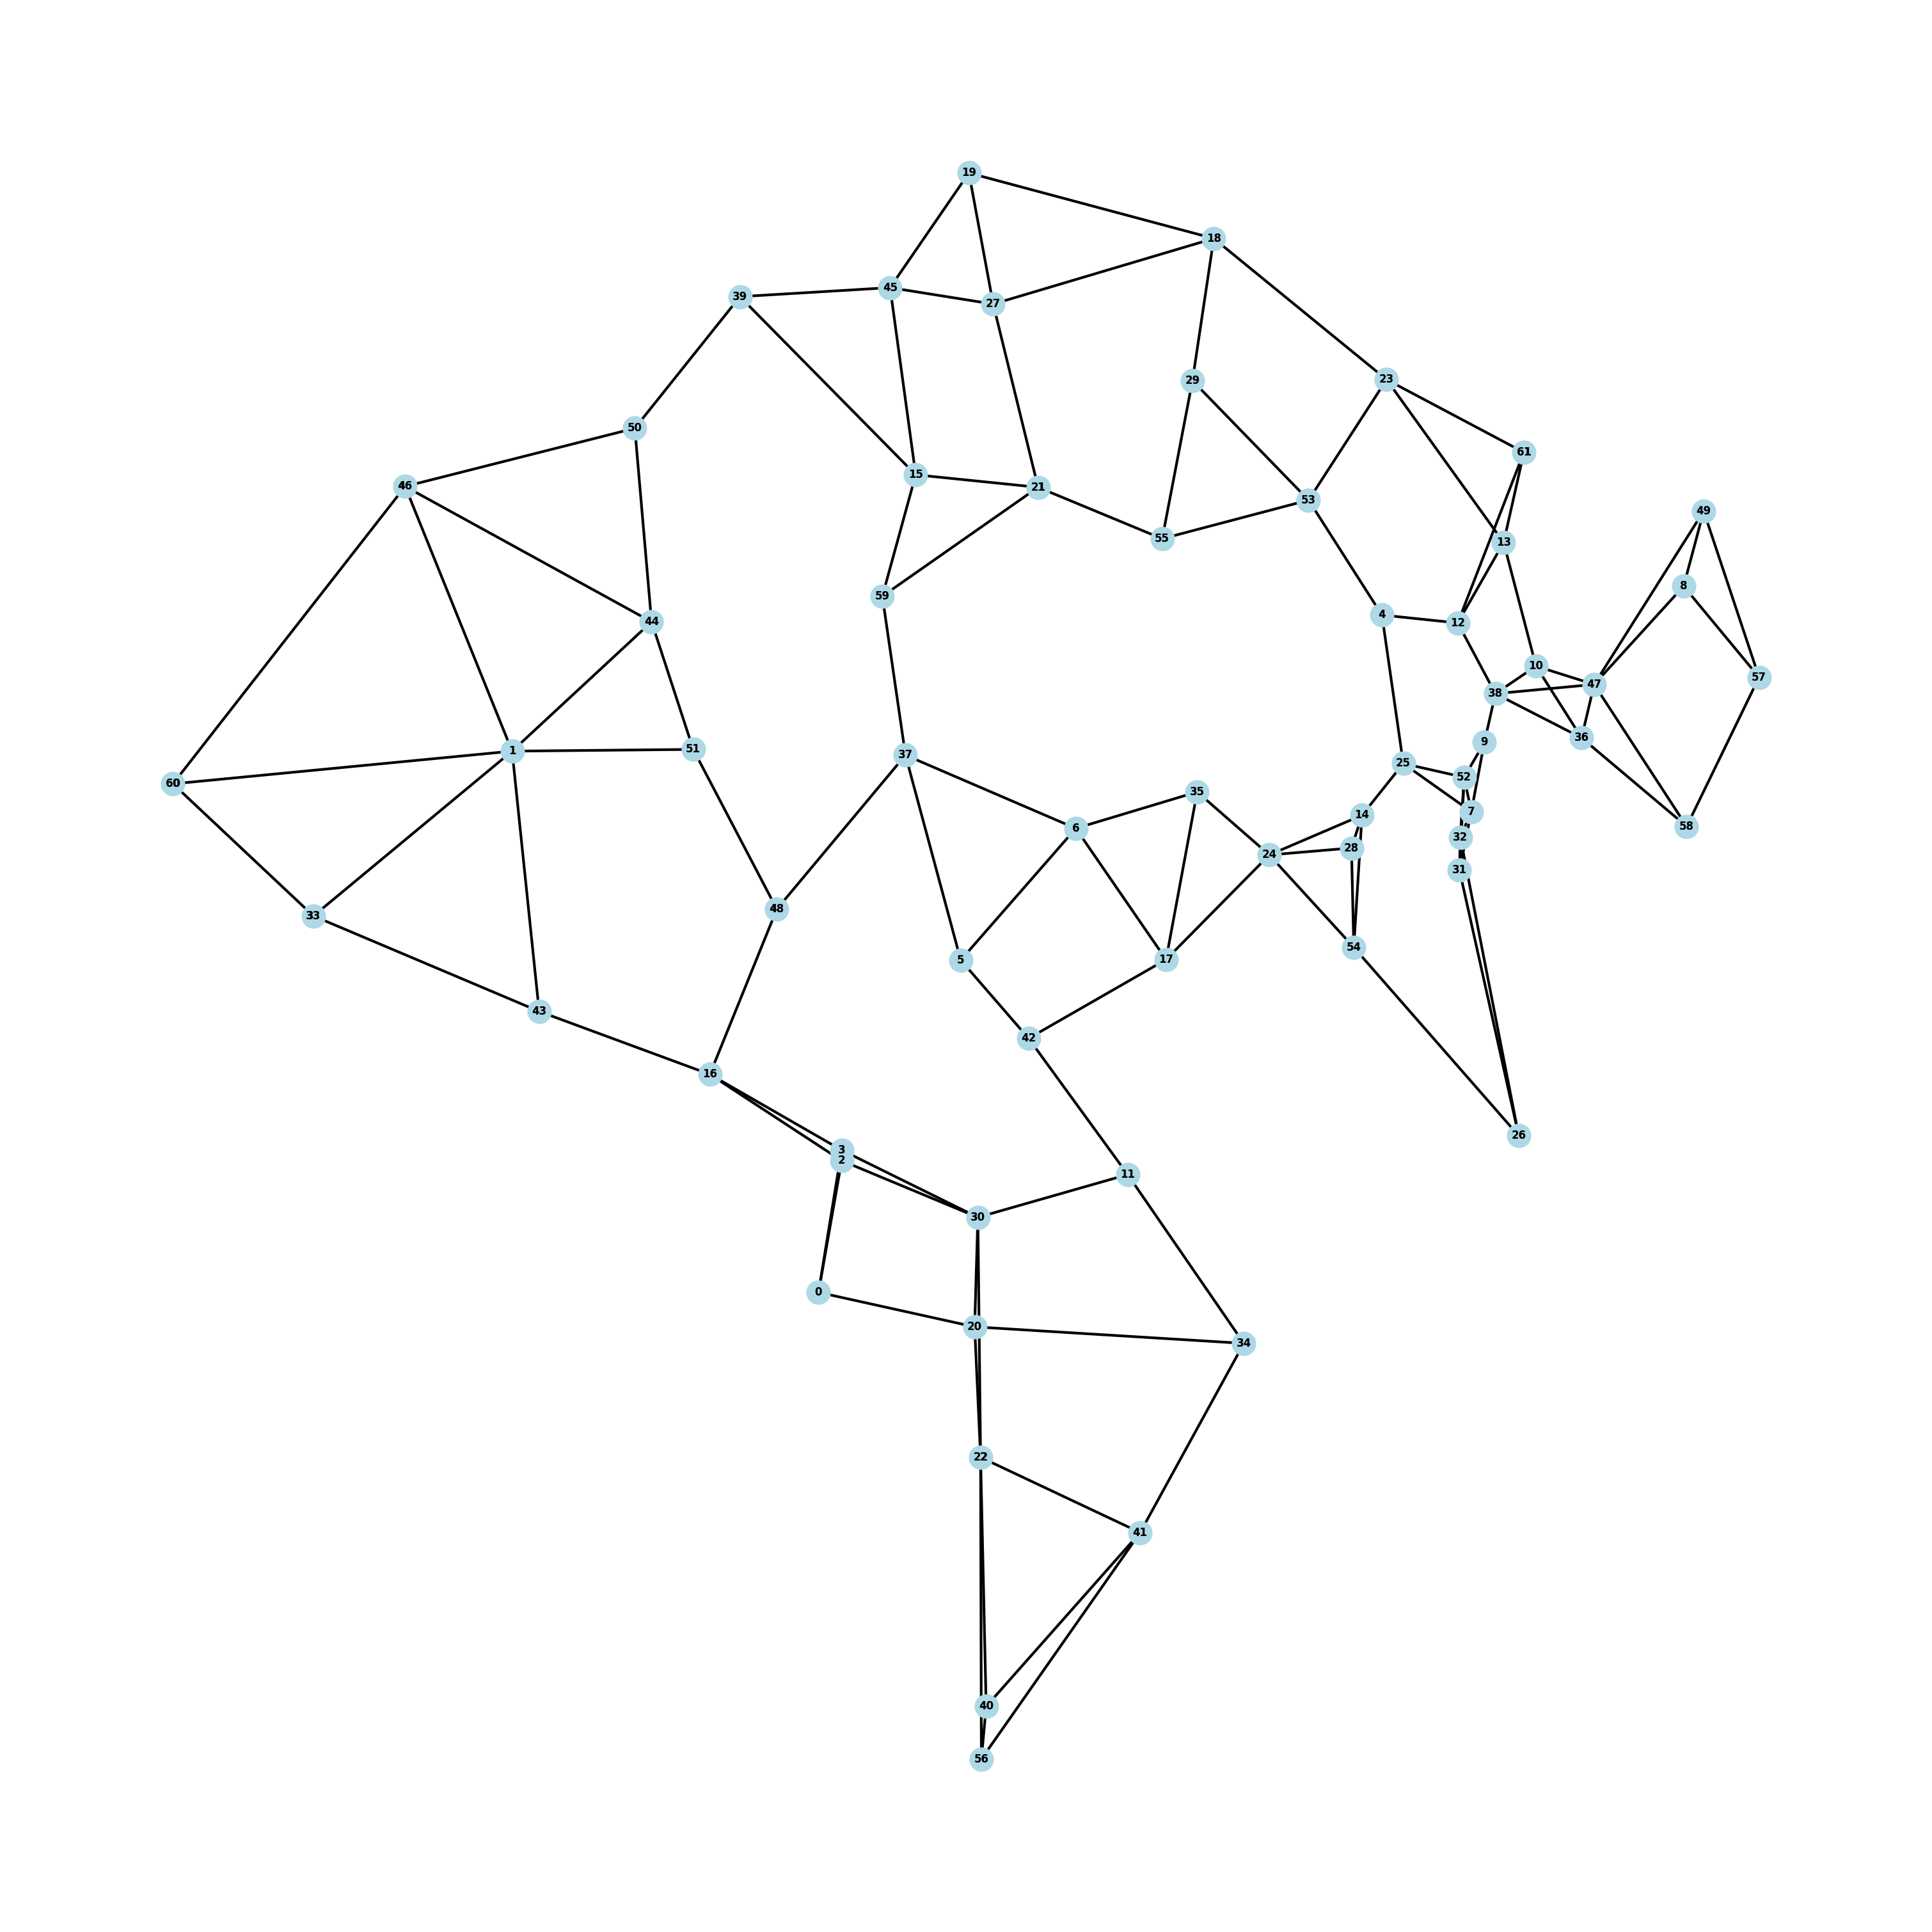

In [ ]:
import os
import copy
import json
import time
from pathlib import Path
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import xarray as xr
import torch
import time
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn.conv import GCNConv, ChebConv
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from dateutil.relativedelta import relativedelta
import sys
sys.path.append("../src")
from dateutil.relativedelta import relativedelta

from Models.model import GLSTM_v2
from Data.file_utils import create_next_experiment_folder
from Models.models_utils import reset_weights
from Data.prepare_data import *
from Data.preprocessing import (normalize_tp, 
                                normalize_features, 
                                assert_finite,
                                fit_log1p_zscore_stats,
                                apply_log1p_zscore,
                                add_consecutive_dry_days_feature)
                                
from Data.feature_extraction import (daily_vertical_velocity, 
                                     get_vv, daily_temp_features, 
                                     get_temp, 
                                     daily_wind_uv_features,
                                     era5_uv_to_tensor,
                                     station_dictionary,
                                     #haversine_km,
                                     tensor_data_precip,
                                     era5_specific_humidity_tensor,
                                     forecast_steps_to_daily_precip,
                                     era5_daily_precip_all,
                                     daily_precip_dataset_to_tensor,
                                     get_wind_uv,
                                     smart_load_dataset
                                     )     
          
from Evaluation.metrics import safe_r2, safe_mape, combined_loss, weighted_mse_loss
from Evaluation.comparison_plots import save_error_plots, plot_heatmap_nn, model_weights_hist, plot_heatmap_nn, scatter_true_pred
from Graph.graph_related_utils import adjacency_matrix, knn_topology, plot_graph, graph_matrix_index, distance_graph
from Training.Training_Routines import train_stable
from Evaluation.predictions import prediction

device = "cuda" if torch.cuda.is_available() else "cpu"

RUN_MODE = "custom"  # quick or full
if RUN_MODE == "full":
    start_date = "2000-01-01"
    end_date   = "2025-12-31"

elif RUN_MODE == "custom":
    start_date = "2015-01-01"
    end_date   = "2025-12-31"

else:
    start_date = "2024-01-01"
    end_date   = "2025-12-31"
    

T = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 1

eps          = 1e-6
window_size  = 30
horizon      = 1
criterion_km = 120
lstm_layers  = 1
dropout      = 0.3
K            = 3
batch_size   = 64
num_workers  = 0
vertex_idx   = 32
weight_decay = 1e-3
test_lstm    = False
learn_adj    = True
loss_fn      = nn.MSELoss()
topology     = 'knn'  # 'knn' ou 'distance'

catalog_dir = Path("..") / "Datasets" / "dados_inmet"
catalog_file = list(catalog_dir.glob("Catalogo*.csv"))[0]
catalogo_inmet = pd.read_csv(catalog_file, sep=';')
estacoes_RS = station_dictionary(catalogo_inmet)



N = len(estacoes_RS)
if topology =='knn':
    edge_index, pos = knn_topology(estacoes_RS, k=K)
else:
    edge_index, edge_weights, pos = distance_graph(estacoes_RS, criterion_km)

plot_graph(N, edge_index, pos)

In [6]:
# Carregamento dos arquivos NetCDF (Datasets)
dataset_load_time = time.time()
rea_tp   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "era5_precipitation_80-26.nc")).sel(time=slice(start_date, end_date))
rea_vv   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "vv_94-25.nc")).sel(time=slice(start_date, end_date))
rea_temp = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "temp_99-25.nc")).sel(time=slice(start_date, end_date))
rea_sh   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "era5_sh_00-25.nc")).sel(time=slice(start_date, end_date))
rea_wind = xr.open_dataset(r"C:\CLimate Change Project\Utils\wind_data\era5_wind_14-25.nc").sel(time=slice(start_date, end_date))
print("Done loading datasets in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time = time.time()
vv_daily_dataset   = daily_vertical_velocity(rea_vv, var_name="w")
print("Done loading vv in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time = time.time()
temp_daily_dataset = daily_temp_features(rea_temp)
print("Done loading temp in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time = time.time()
tp_daily_dataset   = forecast_steps_to_daily_precip(rea_tp, to_mm=True).isel(time=slice(None, -1))
print("Done loading tp in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time = time.time()
wind_daily   = daily_wind_uv_features(rea_wind).isel(time=slice(None, -1))
print("Done loading wind in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
print("Dataset com", temp_daily_dataset.time.values.shape[0], "dias disponíveis.")

Done loading datasets in memory
Time taken: 1.38 seconds
Done loading vv in memory
Time taken: 134.41 seconds
Done loading temp in memory
Time taken: 5.49 seconds
Done loading tp in memory
Time taken: 8.33 seconds
Done loading wind in memory
Time taken: 14.04 seconds
Dataset com 4018 dias disponíveis.


# Extração do dataset do ERA-5





Input features
 - Daily precipitation (1980-2025)
 - vertical velocity of wind (2006-2025)
 - Temperature and dewpoint (2005-2025)
 - u-v components of wind (2014-2025)

The tensor $X$ has shape $[days, nodes, features]$, with all dataset available, with the $X$ we construct the time windows $X_s$ (inputs) and $y_s$ (targets)



In [7]:
#vv_dataset = daily_vertical_velocity(rea_vv, var_name="w")
#temp_dataset = daily_temp_features(rea_temp)

X_tp = daily_precip_dataset_to_tensor(tp_daily_dataset, stations=estacoes_RS).reshape(T, N, 1)

X_year = torch.tensor(
    [[np.sin(np.pi * (t % 365 + 1) / 365) for _ in range(N)] for t in range(T)],
    dtype=torch.float32,
).reshape(T, N, 1)

X_temp = get_temp(start_date, end_date, temp_daily_dataset, estacoes_RS)

X_vv = get_vv(start_date, end_date, vv_daily_dataset, estacoes_RS)

X_sh = era5_specific_humidity_tensor(os.path.join("..", "Datasets", "nc_files", "era5_sh_00-25.nc"), estacoes_RS, start=start_date, end=end_date, var_name="q")

#X_wind = get_wind_uv(start_date, end_date, wind_daily, estacoes_RS, levels=(500,850))

X_wind = era5_uv_to_tensor(r"C:\Climate Change Project\Utils\wind_data\era5_wind_14-25.nc",
                           estacoes_RS,
                           start=start_date,
                           end=end_date,
                           u_var="u",
                           v_var="v"
                           ).reshape(X_tp.shape[0], X_tp.shape[1], -1)

In [3]:
# Carregamento dos arquivos NetCDF (Datasets)

dataset_path = os.path.join("..", "Datasets", "nc_files")

dataset_load_time = time.time()
rea_tp   = smart_load_dataset(dataset_path, "precipitation").sel(time=slice(start_date, end_date))
rea_vv   = smart_load_dataset(dataset_path, "vv").sel(time=slice(start_date, end_date))
rea_temp = smart_load_dataset(dataset_path, "temp").sel(time=slice(start_date, end_date))
rea_sh   = smart_load_dataset(dataset_path, "sh").sel(time=slice(start_date, end_date))
rea_wind = smart_load_dataset(dataset_path, "wind").sel(time=slice(start_date, end_date))
print("Done loading datasets in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
vv_daily_dataset   = daily_vertical_velocity(rea_vv, var_name="w")
temp_daily_dataset = daily_temp_features(rea_temp)
tp_daily_dataset   = forecast_steps_to_daily_precip(rea_tp, to_mm=True).isel(time=slice(None, -1))

print("Dataset com", temp_daily_dataset.time.values.shape[0], "dias disponíveis.")

ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'scipy']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

# Creating temporal dataset

The tensor X is transformed in two new tensors, $X_s$ and $y_s$ (inputs and targets), such that: 

 - $X_s$: $[B, W_{in}, N, F]$;
 - $y_s$: $[B, W_{out}, N]$;
 - $B$ : number of time windows created, with $W_{in}$ days of feed to forecast the next $W_{out}$ days;
 - $N$  : number of nodes (stations)
 - $F$  : number of input features by node



In [8]:
X = torch.cat([X_tp, X_year, X_temp, X_vv, X_sh, X_wind], dim=-1)


X[...,0] = torch.log1p(X[...,0])

In [9]:
#CRIAÇÃO DE JANELAS DE TEMPO
print("Janela de entrada: "+str(window_size)+" dias, horizonte de previsão: "+str(horizon)+" dias")
X_train, y_train, X_val, y_val, X_test, y_test_raw = temporal_train_val_test_split(
    X,
    X[..., 0],
    window_size=window_size,
    horizon=horizon,
    train_ratio=0.7,
    val_ratio=0.2,
    use_context=True,
)

""""
target_mean, target_std = fit_log1p_zscore_stats(X_train, y_train, target_col=0)

X_train[..., 0] = apply_log1p_zscore(X_train[..., 0], target_mean, target_std)
X_val[..., 0] = apply_log1p_zscore(X_val[..., 0], target_mean, target_std)
X_test[..., 0] = apply_log1p_zscore(X_test[..., 0], target_mean, target_std)

y_train = apply_log1p_zscore(y_train, target_mean, target_std)
y_val = apply_log1p_zscore(y_val, target_mean, target_std)
y_test = apply_log1p_zscore(y_test_raw, target_mean, target_std)


X_train[...,0] = torch.log1p(X_train[...,0])
X_val[...,0] = torch.log1p(X_val[...,0])
X_test[...,0] = torch.log1p(X_test[...,0])

y_train = torch.log1p(y_train)
y_val = torch.log1p(y_val)
y_test = torch.log1p(y_test_raw)

"""

# padroniza apenas features exogenas (colunas 2:)
X_train[..., 2:], scalers = normalize_features(X_train[..., 2:], scaler=StandardScaler)

for i, sc in enumerate(scalers):
    X_val[..., 2 + i] = torch.tensor(
        sc.transform(X_val[..., 2 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_val[..., 2 + i].shape)
    X_test[..., 2 + i] = torch.tensor(
        sc.transform(X_test[..., 2 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_test[..., 2 + i].shape)


"""
normalization_stats = {
    "target_mean": float(target_mean),
    "target_std": float(target_std),
}
print("normalization_stats:", normalization_stats)
"""
# Train/val split and DataLoaders
train_loader, val_loader, test_loader = create_batchs(X_train, X_val, X_test, y_train, y_val, y_test_raw, batch_size, device=device, num_workers=num_workers)
print("train batches:", len(train_loader), "val batches:", len(val_loader), "test batches:", len(test_loader))

Janela de entrada: 30 dias, horizonte de previsão: 1 dias
train batches: 44 val batches: 13 test batches: 7


# Training


## GLSTM Stability Patch

Mudanças implementadas aqui:
- `A` deixa de ser uma matriz densa totalmente livre e passa a aprender apenas pesos nas arestas do grafo original.
- a adjac?ncia usada no `forward` ? normalizada por grau a cada passo.
- o estado de célula `C_t` passa por `cell clipping`.
- `reset_parameters()` agora tamb?m reinicializa os parâmetros da adjac?ncia.
- o treino usa `lr` menor para os logits da adjacência e faz `clamp` desses logits após cada `optimizer.step()`.

As células de experimento abaixo já foram apontadas para `GLSTMBatchStable`, `reset_weights_stable` e `train_batched_only_stable` para facilitar a validação.



In [12]:
# Valida??o r?pida da se??o est?vel
stable_probe = GLSTM_v2(
    N=N,
    edge_index=edge_index,
    in_channels=X_train.shape[-1],
    hidden_size=32,
    out_channels=horizon,
    lstm_layers=1,
    learn_adj=True,
    dropout=dropout,
    cell_clip=5.0,
).to(device)
stable_probe.apply(reset_weights)

A_probe = stable_probe.cell_0.current_adjacency().detach().cpu()
print("GLSTM_STABILITY_PATCH_V1 ativo")
print("A_norm row-sum min/max:", float(A_probe.sum(dim=1).min()), float(A_probe.sum(dim=1).max()))
print("A_norm spectral norm:", float(torch.linalg.svdvals(A_probe).max()))
print("A_mask trainable entries:", int(stable_probe.cell_0.edge_mask.sum().item()))


GLSTM_STABILITY_PATCH_V1 ativo
A_norm row-sum min/max: 0.8654723167419434 1.2324895858764648
A_norm spectral norm: 0.9999999403953552
A_mask trainable entries: 230


In [13]:
def make_weighted_mse_loss_log1p_zscore(
    y_train_z,
    target_mean,
    target_std,
    extreme_quantile=0.90,
    extreme_weight=10.0,
    normalize_weights=True,
    eps=1e-6,
):
    """
    Weighted MSE para alvos já transformados com log1p + z-score.

    A ideia é simples:
    - o erro continua sendo calculado no espaço normalizado, que é o espaço do treino;
    - o cutoff de evento extremo é congelado a partir da distribuição de y_train
      também nesse mesmo espaço, evitando threshold diferente em cada batch.

    Como log1p + z-score preserva a ordem dos valores, um quantil calculado em
    y_train_z corresponde ao mesmo quantil na escala física.
    """
    y_train_z = y_train_z.detach().reshape(-1).to(torch.float32)
    z_threshold = torch.quantile(y_train_z, extreme_quantile).item()
    raw_threshold_mm = float(np.expm1(z_threshold * float(target_std) + float(target_mean)))

    def weighted_mse_loss(y_pred, y_true):
        weights = torch.ones_like(y_true)
        weights = torch.where(
            y_true >= z_threshold,
            torch.full_like(y_true, float(extreme_weight)),
            weights,
        )

        if normalize_weights:
            weights = weights / weights.mean().clamp_min(eps)

        return torch.mean(weights * (y_pred - y_true) ** 2)

    weighted_mse_loss.z_threshold = z_threshold
    weighted_mse_loss.raw_threshold_mm = raw_threshold_mm
    weighted_mse_loss.extreme_quantile = extreme_quantile
    weighted_mse_loss.extreme_weight = extreme_weight
    weighted_mse_loss.normalize_weights = normalize_weights
    return weighted_mse_loss


weighted_mse_loss = make_weighted_mse_loss_log1p_zscore(
    y_train,
    target_mean=target_mean,
    target_std=target_std,
    extreme_quantile=0.90,
    extreme_weight=10.0,
    normalize_weights=True,
)

print(
    "weighted_mse_loss configured:",
    {
        "z_threshold": round(float(weighted_mse_loss.z_threshold), 4),
        "approx_mm_threshold": round(float(weighted_mse_loss.raw_threshold_mm), 4),
        "extreme_quantile": weighted_mse_loss.extreme_quantile,
        "extreme_weight": weighted_mse_loss.extreme_weight,
        "normalize_weights": weighted_mse_loss.normalize_weights,
    },
)

NameError: name 'target_mean' is not defined

In [11]:
# RUN MODEL
for lr in [1e-3]:
    for hidden_dim in [16]:
        print(f"========================HIDDEN_DIM: {hidden_dim}=============================")

        model = GLSTM_v2(N=N, edge_index=edge_index, in_channels=X_train.shape[-1], hidden_size=hidden_dim,
                            out_channels=horizon, lstm_layers=1, learn_adj=True, dropout=dropout, cell_clip=5.0).to(device)

        model.apply(reset_weights)        
        window_folder = os.path.join("..", "Experiments", "dataset_15_25_26_03 (SOFTPLUS)", f"WINDOW_{window_size}_HORIZON_{horizon}_MSE_lstm_1_log_norm")

        exp_path = create_next_experiment_folder(window_folder)


        TEST_ITER = 1
        for j in range(TEST_ITER):
            #print(f"========================ITERATION {j}=============================")
            model.apply(reset_weights)
            model, hist, summary = train_stable(
                model           = model, 
                train_loader    = train_loader, 
                val_loader      = val_loader, 
                hidden_dim      = hidden_dim, 
                train_period    = window_size,
                epochs          = 300, 
                lr              = lr, 
                weight_decay    = 1e-2, 
                patience        = 30, 
                criterion       = nn.MSELoss(),
                run_dir         = os.path.join(exp_path)
            )

========================HIDDEN_DIM: 16=============================
train_batched_only_stable: use_amp=False adj_lr_factor=0.25
epoch=1/300train_loss=1.569716e+00/val_loss=1.391893e+00/train_mae=8.004561e-01/val_mae=8.310199e-01/val_mape=1.149292e+04/val_r2=-5.042849e-02/val_r2_batch=-5.394017e-02/val_r2_d1=-5.042849e-02
epoch=2/300train_loss=1.131553e+00/val_loss=1.132128e+00/train_mae=8.230514e-01/val_mae=8.536795e-01/val_mape=1.788476e+04/val_r2=1.462031e-01/val_r2_batch=1.261013e-01/val_r2_d1=1.462031e-01
epoch=3/300train_loss=1.041610e+00/val_loss=1.102708e+00/train_mae=8.180443e-01/val_mae=8.308348e-01/val_mape=1.665091e+04/val_r2=1.684086e-01/val_r2_batch=1.494243e-01/val_r2_d1=1.684086e-01
epoch=4/300train_loss=1.016709e+00/val_loss=1.083069e+00/train_mae=8.009515e-01/val_mae=8.172358e-01/val_mape=1.589985e+04/val_r2=1.828115e-01/val_r2_batch=1.650435e-01/val_r2_d1=1.828115e-01
epoch=5/300train_loss=9.992116e-01/val_loss=1.066644e+00/train_mae=7.890710e-01/val_mae=8.066078e-01/

# Post Train analysis


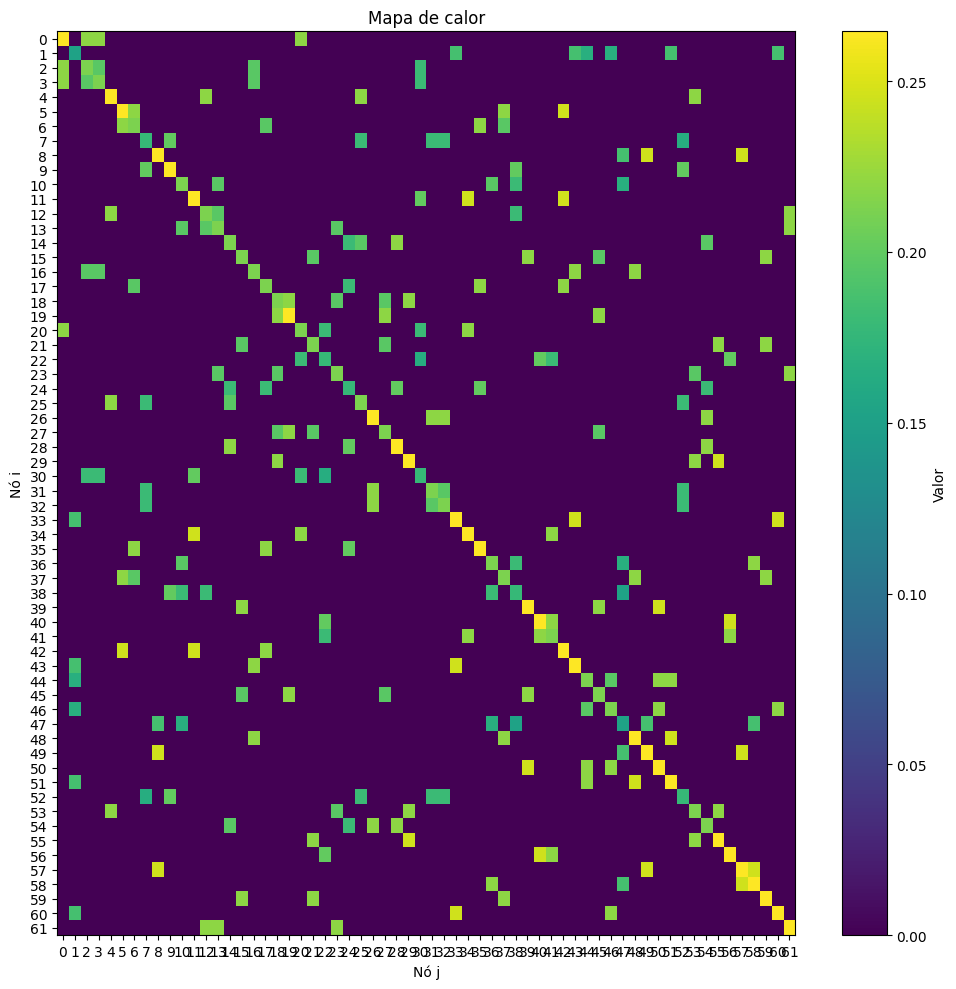

(<Figure size 1000x1000 with 2 Axes>,
 <Axes: title={'center': 'Mapa de calor'}, xlabel='Nó j', ylabel='Nó i'>)

In [15]:
plot_heatmap_nn(model.cell_0.current_adjacency().detach().cpu())

In [ ]:
model.eval()
with torch.no_grad():
    pred  = model(X_test.to(device)).detach().cpu()
    pred_denormalized      = torch.expm1(pred)
    y_test_denormalized    = torch.expm1(y_test_raw)

In [17]:
# DEBUGGING
model.eval()
with torch.no_grad():
    pred  = model(X_test.to(device)).detach().cpu()
    test_r2_global = safe_r2(y_test.reshape(-1), pred.reshape(-1)).item()
    test_r2_by_step = [
        safe_r2(y_test[:, step, :].reshape(-1), pred[:, step, :].reshape(-1)).item()
        for step in range(pred.shape[1])
    ]
    print("test_r2_global:", round(test_r2_global, 4))
    print("test_r2_by_step:", [round(v, 4) for v in test_r2_by_step])
    pred_denormalized      = torch.expm1(pred * target_std + target_mean)
    y_test_denormalized    = torch.expm1(y_test * target_std + target_mean)


NameError: name 'y_test' is not defined

'\ndaily_mean = torch.mean(y_test_raw[:T_max,:,:], dim=-1)\n\n\nplt.figure(figsize=(10,10))\nplt.title("Normalized")\nplt.axhline(y=y_test_raw.mean().item(), color=\'gray\', linestyle=\'--\', label=\'média histórica\')\nplt.plot(daily_mean.reshape(-1,1), label=\'média diária\')\nplt.xlim(0,T_max)\nplt.plot(pred[:T_max,:,vertex_idx].reshape(-1,1), label=\'previsão\')\nplt.plot(y_test_raw[:T_max,:,vertex_idx].reshape(-1,1), label=\'real\')\nplt.legend()\n'

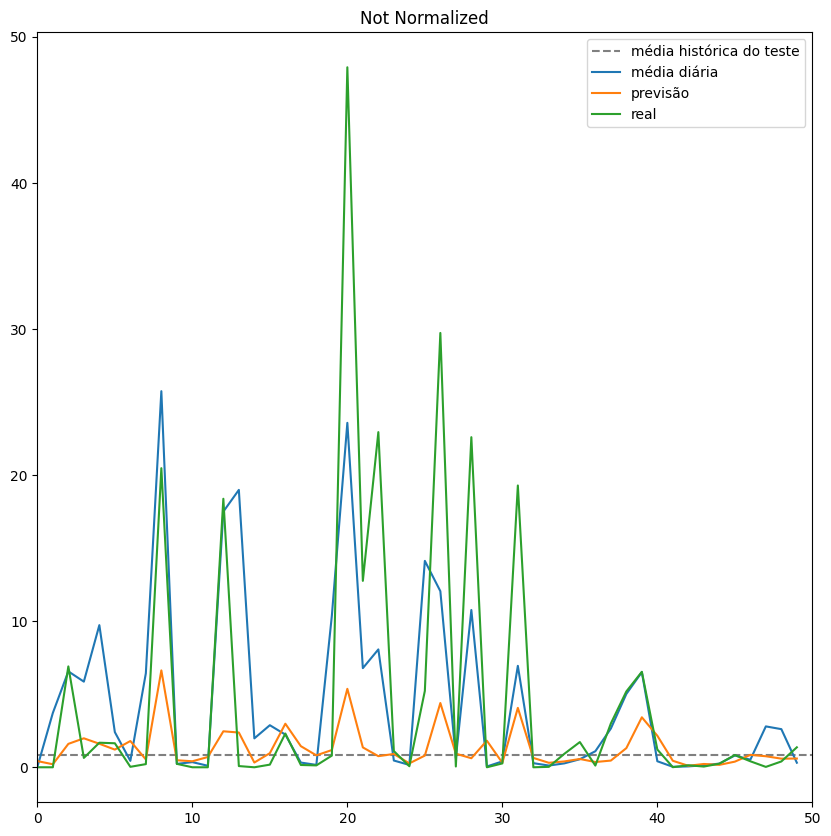

: 

In [ ]:
import matplotlib.pyplot as plt
T_max = 50
vertex_idx=32

daily_mean = torch.mean(y_test_denormalized[:T_max,:,:], dim=-1)

#print(pred.shape, y_test.shape)

plt.figure(figsize=(10,10))
plt.title("Not Normalized")
plt.xlim(0,T_max)
plt.axhline(y=y_test_raw.mean().item(), color='gray', linestyle='--',label='média histórica do teste')
plt.plot(daily_mean.reshape(-1,1), label='média diária')
plt.plot(pred_denormalized[:T_max,:,vertex_idx].reshape(-1,1), label='previsão')
plt.plot(y_test_denormalized[:T_max,:,vertex_idx].reshape(-1,1), label='real')
plt.legend()
plt.savefig(os.path.join(exp_path,"output.png"))


"""
daily_mean = torch.mean(y_test_raw[:T_max,:,:], dim=-1)


plt.figure(figsize=(10,10))
plt.title("Normalized")
plt.axhline(y=y_test_raw.mean().item(), color='gray', linestyle='--', label='média histórica')
plt.plot(daily_mean.reshape(-1,1), label='média diária')
plt.xlim(0,T_max)
plt.plot(pred[:T_max,:,vertex_idx].reshape(-1,1), label='previsão')
plt.plot(y_test_raw[:T_max,:,vertex_idx].reshape(-1,1), label='real')
plt.legend()
"""

In [132]:
def plot_estacao_unica(y_real, y_pred, station_idx, start_date_plot, station_name=None):
    """
    y_real, y_pred: tensores [T, N] (escala física, ex: mm/dia)
    station_idx: índice do nó/estação
    start_date_plot: ex. "2025-01-01"
    """
    y_real_np = y_real[..., station_idx].detach().cpu().numpy()
    y_pred_np = y_pred[..., station_idx].detach().cpu().numpy()
    datas = pd.date_range(start=start_date_plot, periods=len(y_real_np), freq="D")

    plt.figure(figsize=(12, 4))
    plt.plot(datas, y_real_np, label="ERA5 real", linewidth=2)
    plt.plot(datas, y_pred_np, label="Rede estimado", linewidth=2)
    plt.title(f"Real vs Previsto - nó {station_idx}" if station_name is None else f"Real vs Previsto - {station_name}")
    plt.xlabel("Data")
    plt.ylabel("Precipitação")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def _flatten_unique_days(y, stride=1):
    """
    Remove dias sobrepostos entre batches.
    Espera y com shape [batches, horizon, stations] (ou [batches, horizon]).
    Retorna serie unica no tempo, sem repeticao de dias.
    """
    if hasattr(y, "detach"):
        y = y.detach().cpu().numpy()
    else:
        y = np.asarray(y)

    if y.ndim == 2:
        y = y[:, :, None]  # [batches, horizon, 1]
        squeeze_back = True
    else:
        squeeze_back = False

    if y.ndim != 3:
        raise ValueError(f"y deve ter 2 ou 3 dimensoes. Recebido shape={y.shape}")

    batches, horizon, n_stations = y.shape
    if batches == 0:
        raise ValueError("y esta vazio.")
    if stride < 1:
        raise ValueError("stride deve ser >= 1.")

    if stride >= horizon:
        flat = y.reshape(batches * horizon, n_stations)
    else:
        parts = [y[0]]
        if batches > 1:
            tail = y[1:, -stride:, :].reshape(-1, n_stations)
            parts.append(tail)
        flat = np.concatenate(parts, axis=0)

    if squeeze_back:
        return flat[:, 0]
    return flat


def plot_precip_pred_vs_true(
    y_pred,
    y_true,
    station_idx=0,
    stride=1,
    start_date=None,
    station_name=None,
    ax=None,
    show=True,
    title=None,
):
    """
    Plota precipitacao predita vs real sem repetir dias.

    Parametros
    ----------
    y_pred, y_true : [batches, horizon, stations] (ou [batches, horizon])
        Exemplo: y_pred com shape [batchs, 5, 62].
    station_idx : int ou None
        Indice da estacao. Se None, plota a media das estacoes.
    stride : int
        Deslocamento entre batches. Para janelas deslizantes diarias, use 1.
    start_date : str ou None
        Data inicial (YYYY-MM-DD) para eixo x. Se None, usa indice.
    """
    y_pred_flat = _flatten_unique_days(y_pred, stride=stride)
    y_true_flat = _flatten_unique_days(y_true, stride=stride)

    if y_pred_flat.shape[0] != y_true_flat.shape[0]:
        raise ValueError(
            f"Tamanho temporal diferente: pred={y_pred_flat.shape[0]} vs true={y_true_flat.shape[0]}"
        )

    if y_pred_flat.ndim == 1:
        pred_series = y_pred_flat
        true_series = y_true_flat
        label = "serie"
    else:
        if station_idx is None:
            pred_series = y_pred_flat.mean(axis=1)
            true_series = y_true_flat.mean(axis=1)
            label = "media_estacoes"
        else:
            pred_series = y_pred_flat[:, station_idx]
            true_series = y_true_flat[:, station_idx]
            label = f"estacao {station_idx}" if station_name is None else station_name

    if start_date is not None:
        x = pd.date_range(start=start_date, periods=len(true_series), freq="D")
        xlabel = "Data"
    else:
        x = np.arange(len(true_series))
        xlabel = "Dia"

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    else:
        fig = ax.figure

    ax.plot(x, true_series, label="real", linewidth=2)
    ax.plot(x, pred_series, label="predito", linewidth=2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Precipitacao")
    ax.set_title(title or f"Precipitacao real vs predita - {label}")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()

    if show:
        plt.show()

    return fig, ax

def prever_futuro_precip_todos_nos(
    model,
    X_hist_ready,              # [T_hist, N, F] já no mesmo pré-processamento do treino
    horizon,                   # número de dias/passos futuros
    train_period,              # mesmo train_period usado no treino
    future_exog_ready=None,    # [horizon, N, F] (opcional). Se None, replica último passo
    target_col=0,              # coluna da precipitação nas features
    device=None,
    inverse_transformer=None,  # ex: pt_x (PowerTransformer), opcional
):
    """
    Retorna:
      pred_scaled: [horizon, N] na escala do modelo
      pred_real:   [horizon, N] em escala física (se inverse_transformer for fornecido), senão None
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    n_in = model.cell.W_i.in_features
    seq_len = train_period - 1

    if X_hist_ready.ndim != 3:
        raise ValueError("X_hist_ready deve ter shape [T_hist, N, F].")
    if X_hist_ready.shape[0] < seq_len:
        raise ValueError(f"Histórico insuficiente: precisa de pelo menos {seq_len} passos.")
    if future_exog_ready is not None and future_exog_ready.shape[0] < horizon:
        raise ValueError("future_exog_ready tem menos passos que horizon.")

    X_hist_ready = X_hist_ready[:, :, :n_in].float().cpu()
    if future_exog_ready is not None:
        future_exog_ready = future_exog_ready[:, :, :n_in].float().cpu()

    window = X_hist_ready[-seq_len:].clone()  # [seq_len, N, F]
    preds = []

    with torch.no_grad():
        for h in range(horizon):
            y_hat = model(window.unsqueeze(0).to(device)).squeeze(0).detach().cpu()  # [N]
            preds.append(y_hat)
            next_step = window[-1].clone() if future_exog_ready is None else future_exog_ready[h].clone()
            next_step[:, target_col] = y_hat  # autoregressivo
            window = torch.cat([window[1:], next_step.unsqueeze(0)], dim=0)

    pred_scaled = torch.sack(preds, dim=0)  # [horizon, N]

    pred_real = None
    if inverse_transformer is not None:
        arr = pred_scaled.numpy().reshape(-1, 1)
        inv = inverse_transformer.inverse_transform(arr).reshape(pred_scaled.shape)
        pred_real = torch.tensor(inv, dtype=torch.float32)

    return pred_scaled, pred_real


# Pipeline Test


In [ ]:
print(X.shape)
X_pipe = X[-40:] 
print(X_pipe.shape)

X_train_pipe, y_train_pipe, X_val_pipe, y_val_pipe, X_test_pipe, y_test_pipe = train_split(X_pipe, X_pipe[...,0], window_size, horizon)

torch.Size([731, 62, 13])
torch.Size([731, 62, 13])


In [120]:
#CRIAÇÃO DE JANELAS DE TEMPO

X_train, y_train, X_val, y_val, X_test, y_test_raw = temporal_train_val_test_split(
    X,
    X[..., 0],
    window_size=window_size,
    horizon=horizon,
    train_ratio=0.7,
    val_ratio=0.2,
    use_context=True,
)

scaler_tp = StandardScaler()



target_mean, target_std = fit_exp1m_zscore_stats(X_train, y_train, target_col=0)


X_train[..., 0] = apply_expm1_zscore(X_train[..., 0], target_mean, target_std)
X_val[..., 0] = apply_expm1_zscore(X_val[..., 0], target_mean, target_std)
X_test[..., 0] = apply_expm1_zscore(X_test[..., 0], target_mean, target_std)

y_train = apply_expm1_zscore(y_train, target_mean, target_std)
y_val = apply_expm1_zscore(y_val, target_mean, target_std)
y_test = apply_expm1_zscore(y_test_raw, target_mean, target_std)


"""
X_train[...,0] = torch.log1p(X_train[...,0])
X_val[...,0] = torch.log1p(X_val[...,0])
X_test[...,0] = torch.log1p(X_test[...,0])

y_train = torch.log1p(y_train)
y_val = torch.log1p(y_val)
y_test = torch.log1p(y_test_raw)
"""

# padroniza apenas features exogenas (colunas 2:)
X_train[..., 2:], scalers = normalize_features(X_train[..., 2:], scaler=StandardScaler)

for i, sc in enumerate(scalers):
    X_val[..., 2 + i] = torch.tensor(
        sc.transform(X_val[..., 2 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_val[..., 2 + i].shape)
    X_test[..., 2 + i] = torch.tensor(
        sc.transform(X_test[..., 2 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_test[..., 2 + i].shape)


"""
normalization_stats = {
    "target_mean": float(target_mean),
    "target_std": float(target_std),
}
print("normalization_stats:", normalization_stats)
"""
# Train/val split and DataLoaders
train_loader, val_loader, test_loader = create_batchs(X_train, X_val, X_test, y_train, y_val, y_test, batch_size, device=device, num_workers=num_workers)
print("train batches:", len(train_loader), "val batches:", len(val_loader), "test batches:", len(test_loader))



train batches: 8 val batches: 3 test batches: 2


In [ ]:
for lr in [1e-3]:
    for hidden_dim in [64]:
        print(f"========================HIDDEN_DIM: {hidden_dim}=============================")

        model = GLSTMBatchStable(N=N, edge_index=edge_index, in_channels=X_train.shape[-1], hidden_size=hidden_dim,
                            out_channels=horizon, lstm_layers=1, learn_adj=True, dropout=dropout, cell_clip=5.0).to(device)

        model.apply(reset_weights_stable)        
        window_folder = os.path.join("..", "Experiments", "pipeline_test_tp_vv_stability_patch", f"WINDOW_{window_size}_HORIZON_{horizon}")

        exp_path = create_next_experiment_folder(window_folder)


        TEST_ITER = 1
        for j in range(TEST_ITER):
            #print(f"========================ITERATION {j}=============================")
            model.apply(reset_weights_stable)
            model, hist, summary = train_batched_only_stable(
                model, train_loader, val_loader, hidden_dim=hidden_dim, train_period=window_size,
                epochs=150, lr=lr, weight_decay=1e-5, patience=30, criterion=nn.MSELoss(),run_dir=os.path.join(exp_path, f"BATCH_TEST_{j}")
            )

# Correlation analysis


In [20]:
X[:,:, 0].reshape(-1, X.shape[0]).shape

torch.Size([62, 5844])

In [21]:
corrcoef_matrix = torch.corrcoef(X[:,:, 0].reshape(-1, X.shape[0]).T)

#corrcoef_matrix = torch.corrcoef(X[...,0].reshape(-1,X.shape[2]).T)

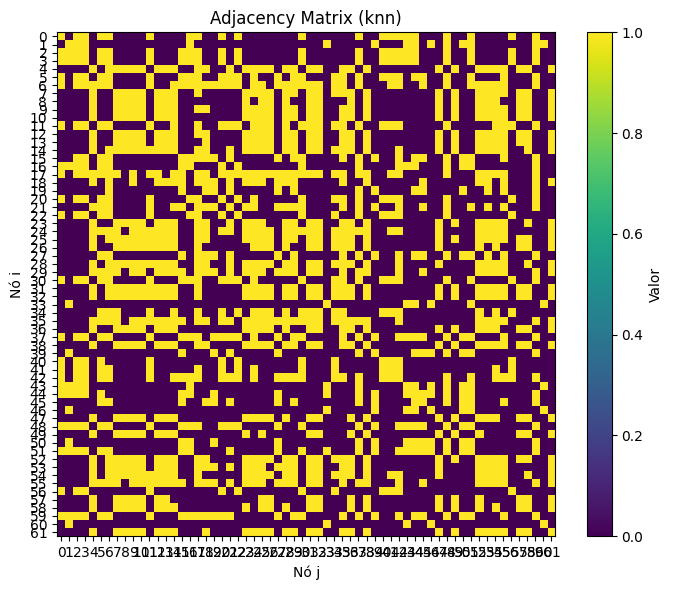

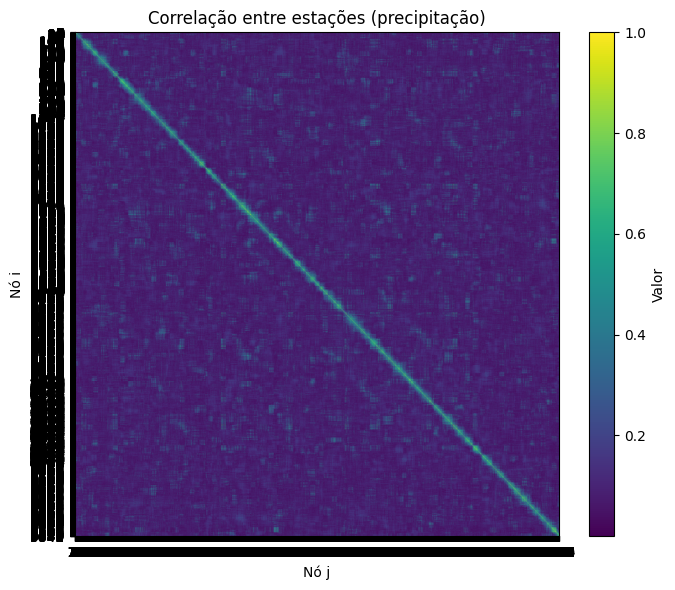

(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'Correlação entre estações (precipitação)'}, xlabel='Nó j', ylabel='Nó i'>)

In [22]:
plot_heatmap_nn(adjacency_matrix(N, distance_graph(estacoes_RS, criterion=200)[0]), title="Adjacency Matrix (knn)")

plot_heatmap_nn(torch.abs(corrcoef_matrix), title="Correlação entre estações (precipitação)")

In [77]:
print(torch.abs(corrcoef_matrix).min())

tensor(0.0005)


(array([ 12.,  34.,  48., 170., 244., 454., 666., 816., 814., 586.]),
 array([0.14781022, 0.2330292 , 0.31824818, 0.40346718, 0.48868614,
        0.57390511, 0.65912414, 0.7443431 , 0.82956207, 0.91478103,
        1.        ]),
 <BarContainer object of 10 artists>)

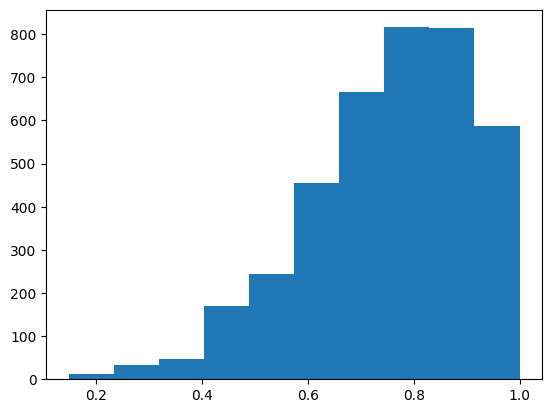

In [67]:
plt.hist(corrcoef_matrix.reshape(-1,1).numpy())

In [ ]:
for lr in [5e-4]:
    for hidden_dim in [512]:
        print(f"========================HIDDEN_DIM: {hidden_dim}=============================")

        model = GLSTMBatchStable(N=N, edge_index=edge_index, in_channels=X_train.shape[-1], hidden_size=hidden_dim,
                            out_channels=horizon, lstm_layers=1, learn_adj=True, dropout=dropout, cell_clip=5.0).to(device)

        model.apply(reset_weights_stable)        
        window_folder = os.path.join("..", "Experiments", "pipeline_test_stability_patch")

        exp_path = create_next_experiment_folder(window_folder)


        TEST_ITER = 1
        for j in range(TEST_ITER):
            #print(f"========================ITERATION {j}=============================")
            model.apply(reset_weights_stable)
            model, hist, summary = train_batched_only_stable(
                model, train_loader, val_loader, hidden_dim=hidden_dim, train_period=window_size,
                epochs=3000, lr=lr, weight_decay=1e-3, patience=3000, criterion=weighted_mse_loss,run_dir=os.path.join(exp_path, f"BATCH_TEST_{j}")
            )